# 02 — Logistic Regression Baseline

My baseline classifier for the project. I keep the public API identical to `baseline_nn.py` so the downstream calibration and abstention code can use either model without branching.

In this notebook I train on Breast Cancer, report the standard classification metrics alongside calibration metrics (ECE, Brier, reliability diagram), inspect coefficients briefly, and save the trained model plus predictions so the shift and calibration notebooks can load them directly.

In [1]:
import sys, os, json, pickle
from pathlib import Path

# Make the repo root importable from notebooks/.
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    log_loss,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
)
from sklearn.calibration import calibration_curve

from src.models.baseline_logistic import LogisticRegressionClassifier

RANDOM_STATE = 42
ARTIFACT_DIR = Path("../artifacts/baselines")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

## 1. Data and splits

Breast Cancer Wisconsin (30 real-valued features, binary target). I use two split conventions:

- **80 / 20 train / test** — matches `main.ipynb` exactly (same seed and stratification) so my LR can be compared side-by-side with the NN on identical test points.
- **60 / 20 / 20 train / calibration / test** — the downstream temperature-scaling and split-conformal methods need a held-out calibration set. I train a second model on this split and save the cal-set logits so that work can use them directly.

In [2]:
data = load_breast_cancer()
X, y = data.data, data.target
feature_names = data.feature_names

print(f"n = {X.shape[0]}, d = {X.shape[1]}")
print(f"class balance: {dict(zip(*np.unique(y, return_counts=True)))}")
print(f"classes: {data.target_names.tolist()}  (0 = malignant, 1 = benign)")

n = 569, d = 30
class balance: {np.int64(0): np.int64(212), np.int64(1): np.int64(357)}
classes: ['malignant', 'benign']  (0 = malignant, 1 = benign)


In [3]:
# 80/20 split
X_train_82, X_test_82, y_train_82, y_test_82 = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# 60/20/20 split
X_trainval, X_test_622, y_trainval, y_test_622 = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
X_train_622, X_cal_622, y_train_622, y_cal_622 = train_test_split(
    X_trainval, y_trainval,
    test_size=0.25,  # 0.25 * 0.8 = 0.20 of the original
    random_state=RANDOM_STATE,
    stratify=y_trainval,
)

print("80/20 :", X_train_82.shape, X_test_82.shape)
print("60/20/20 :", X_train_622.shape, X_cal_622.shape, X_test_622.shape)

80/20 : (455, 30) (114, 30)
60/20/20 : (341, 30) (114, 30) (114, 30)


In [4]:
# z-score standardization — fit on training only, then apply to the rest.
def fit_and_apply(X_tr, *others):
    s = StandardScaler().fit(X_tr)
    return (s, s.transform(X_tr)) + tuple(s.transform(X) for X in others)

scaler_82, X_train_82_s, X_test_82_s = fit_and_apply(X_train_82, X_test_82)
scaler_622, X_train_622_s, X_cal_622_s, X_test_622_s = fit_and_apply(
    X_train_622, X_cal_622, X_test_622
)

## 2. Training

I use L2 regularization and let the classifier's internal cross-validation pick `C = 1 / lambda` over a log-spaced grid using log-loss. L2 (Gaussian prior under the MAP view we covered in class) is a sensible default when I don't have a prior reason to expect many features to be exactly irrelevant. Tuning `C` on held-out data rather than assuming a value is the standard approach we discussed.

In [5]:
model = LogisticRegressionClassifier(
    penalty="l2",
    random_state=RANDOM_STATE,
).fit(X_train_82_s, y_train_82)

print(f"selected C = {model.selected_C_}")
print(f"classes_   = {model.classes_}")

selected C = 1.0
classes_   = [0 1]


## 3. Evaluation on clean (in-distribution) data

I report three groups of metrics:

- **Discrimination:** accuracy, AUC, confusion matrix.
- **Calibration:** log-loss, Brier, 10-bin ECE, reliability diagram. This is the metric family the project is really about — I want baseline numbers here so we can measure degradation under shift.
- **Interpretability:** a quick look at the standardized coefficients.

In [6]:
logits_test = model.predict_logits(X_test_82_s)
probs_test = model.predict_proba(X_test_82_s)
preds_test = model.predict(X_test_82_s)

acc   = accuracy_score(y_test_82, preds_test)
auc   = roc_auc_score(y_test_82, probs_test[:, 1])
ll    = log_loss(y_test_82, probs_test)
brier = brier_score_loss(y_test_82, probs_test[:, 1])

print(f"Accuracy : {acc:.4f}")
print(f"ROC-AUC  : {auc:.4f}")
print(f"Log-loss : {ll:.4f}")
print(f"Brier    : {brier:.4f}")
print()
print(classification_report(y_test_82, preds_test, target_names=data.target_names))

Accuracy : 0.9825
ROC-AUC  : 0.9954
Log-loss : 0.0778
Brier    : 0.0216

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



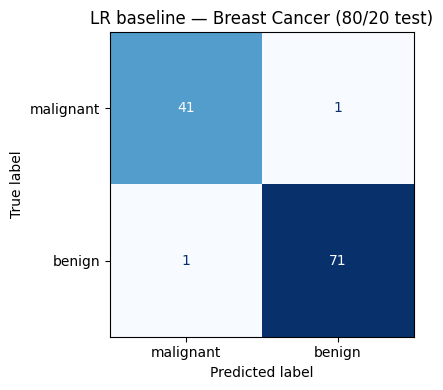

In [7]:
cm = confusion_matrix(y_test_82, preds_test)
fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay(cm, display_labels=data.target_names).plot(
    ax=ax, colorbar=False, cmap="Blues"
)
ax.set_title("LR baseline — Breast Cancer (80/20 test)")
plt.tight_layout(); plt.show()

### 3.1 ROC curve

The default 0.5 threshold isn't always the right one, so I also report the Youden-optimal threshold (max of TPR − FPR) as a sanity check. I keep 0.5 at inference for comparability with the NN baseline.

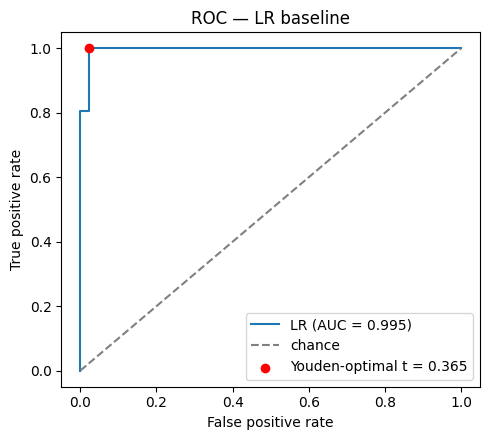

In [8]:
fpr, tpr, thresholds_roc = roc_curve(y_test_82, probs_test[:, 1])
J = tpr - fpr
j_idx = int(np.argmax(J))
t_star = thresholds_roc[j_idx]

fig, ax = plt.subplots(figsize=(5, 4.5))
ax.plot(fpr, tpr, label=f"LR (AUC = {auc:.3f})")
ax.plot([0, 1], [0, 1], "--", color="grey", label="chance")
ax.scatter([fpr[j_idx]], [tpr[j_idx]], color="red", zorder=5,
           label=f"Youden-optimal t = {t_star:.3f}")
ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
ax.set_title("ROC — LR baseline")
ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

### 3.2 Reliability diagram and ECE

A classifier is calibrated if, among all examples it assigns probability `p`, the empirical positive rate is also `p`. I bin predictions by confidence, plot bin frequency against mean predicted probability, and report the bin-size-weighted gap (Expected Calibration Error). These numbers are the in-distribution reference — once we apply distribution shift, the increase in ECE / Brier is what we're measuring.

ECE (10 bins): 0.0321


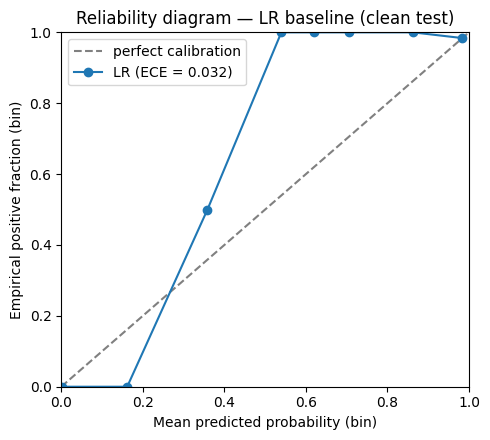

In [9]:
def expected_calibration_error(y_true, probs_pos, n_bins=10):
    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_ids = np.clip(np.digitize(probs_pos, bin_edges[1:-1]), 0, n_bins - 1)
    ece = 0.0
    n = len(y_true)
    for b in range(n_bins):
        mask = bin_ids == b
        if not np.any(mask):
            continue
        conf_b = probs_pos[mask].mean()
        acc_b = y_true[mask].mean()
        ece += (mask.sum() / n) * abs(conf_b - acc_b)
    return ece

ece = expected_calibration_error(y_test_82, probs_test[:, 1], n_bins=10)
print(f"ECE (10 bins): {ece:.4f}")

frac_pos, mean_pred = calibration_curve(
    y_test_82, probs_test[:, 1], n_bins=10, strategy="uniform"
)

fig, ax = plt.subplots(figsize=(5, 4.5))
ax.plot([0, 1], [0, 1], "--", color="grey", label="perfect calibration")
ax.plot(mean_pred, frac_pos, "o-", label=f"LR (ECE = {ece:.3f})")
ax.set_xlabel("Mean predicted probability (bin)")
ax.set_ylabel("Empirical positive fraction (bin)")
ax.set_title("Reliability diagram — LR baseline (clean test)")
ax.legend(loc="upper left"); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
plt.tight_layout(); plt.show()

### 3.3 Coefficients

Because I standardized features, `|w_j|` is comparable across features, so a simple ranking shows what the model is leaning on most. As we discussed in class, coefficient magnitudes need to be read with care when features are collinear (many of the Breast Cancer features are), and the intercept corresponds to the standardized origin rather than any real patient — so this is a rough interpretability signal rather than a causal story.

intercept b = 0.2991


,feature,coef,|coef|
0,worst texture,-1.250914,1.250914
1,radius error,-1.084679,1.084679
2,worst area,-0.952523,0.952523
3,worst concave points,-0.950336,0.950336
4,worst radius,-0.946519,0.946519
5,worst symmetry,-0.936043,0.936043
6,area error,-0.933508,0.933508
7,worst concavity,-0.826083,0.826083
8,worst perimeter,-0.762383,0.762383
9,worst smoothness,-0.752661,0.752661


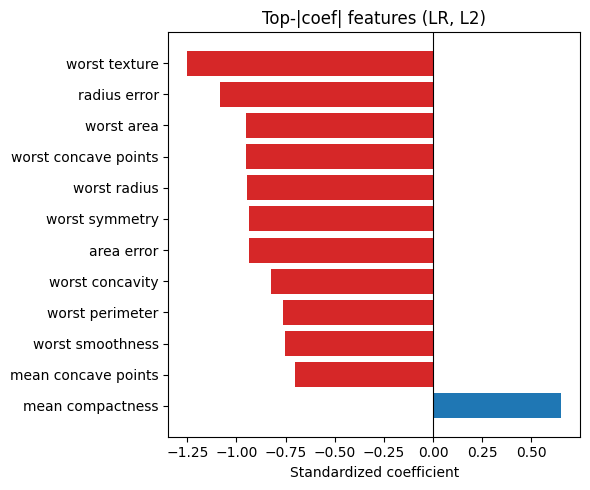

In [10]:
w, b = model.get_coefficients()
coef_df = (
    pd.DataFrame({"feature": feature_names, "coef": w, "|coef|": np.abs(w)})
    .sort_values("|coef|", ascending=False)
    .reset_index(drop=True)
)
print(f"intercept b = {b:.4f}")
display(coef_df.head(10))

fig, ax = plt.subplots(figsize=(6, 5))
top = coef_df.head(12).iloc[::-1]
colors = ["#d62728" if c < 0 else "#1f77b4" for c in top["coef"]]
ax.barh(top["feature"], top["coef"], color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Standardized coefficient")
ax.set_title("Top-|coef| features (LR, L2)")
plt.tight_layout(); plt.show()

## 4. L1 vs L2 ablation

Quick sanity-check: under the MAP view, L1 corresponds to a Laplace prior and pushes many coefficients to exactly zero, while L2 shrinks smoothly. I want to see whether L1 materially changes performance on this dataset or just produces a sparser model.

In [11]:
model_l1 = LogisticRegressionClassifier(penalty="l1", random_state=RANDOM_STATE).fit(
    X_train_82_s, y_train_82
)
w_l1, _ = model_l1.get_coefficients()

n_nonzero_l2 = int((np.abs(w) > 1e-8).sum())
n_nonzero_l1 = int((np.abs(w_l1) > 1e-8).sum())

probs_l1 = model_l1.predict_proba(X_test_82_s)[:, 1]
acc_l1 = accuracy_score(y_test_82, model_l1.predict(X_test_82_s))
auc_l1 = roc_auc_score(y_test_82, probs_l1)
ll_l1  = log_loss(y_test_82, model_l1.predict_proba(X_test_82_s))
ece_l1 = expected_calibration_error(y_test_82, probs_l1, n_bins=10)

summary = pd.DataFrame(
    {
        "L2": [model.selected_C_,    n_nonzero_l2, acc,    auc,    ll,    ece],
        "L1": [model_l1.selected_C_, n_nonzero_l1, acc_l1, auc_l1, ll_l1, ece_l1],
    },
    index=["selected C", "non-zero coefs / 30", "accuracy", "AUC", "log-loss", "ECE"],
).round(4)
display(summary)

,L2,L1
selected C,1.0000,1.0000
non-zero coefs / 30,30.0000,16.0000
accuracy,0.9825,0.9912
AUC,0.9954,0.9967
log-loss,0.0778,0.0752
ECE,0.0321,0.0405


On this dataset both regularizers land at essentially the same test performance. L1 zeroes out a meaningful fraction of features — useful if we ever want a sparser, more interpretable model, but not necessary here. I use L2 by default going forward.

## 5. Artifacts

I persist the trained model and its predictions on both splits so the calibration, abstention, and shift notebooks don't have to retrain. The 60/20/20 version is the one the calibration code should consume because it has a dedicated held-out calibration set.

In [12]:
# Train on the 60/20/20 split so the model has not seen cal or test.
model_622 = LogisticRegressionClassifier(
    penalty="l2", random_state=RANDOM_STATE
).fit(X_train_622_s, y_train_622)

logits_cal_622  = model_622.predict_logits(X_cal_622_s)
probs_cal_622   = model_622.predict_proba(X_cal_622_s)
logits_test_622 = model_622.predict_logits(X_test_622_s)
probs_test_622  = model_622.predict_proba(X_test_622_s)

with open(ARTIFACT_DIR / "logistic_82.pkl", "wb") as f:
    pickle.dump({"model": model, "scaler": scaler_82}, f)
with open(ARTIFACT_DIR / "logistic_622.pkl", "wb") as f:
    pickle.dump({"model": model_622, "scaler": scaler_622}, f)

np.savez(
    ARTIFACT_DIR / "predictions_82.npz",
    logits_test=logits_test, probs_test=probs_test, y_test=y_test_82,
)
np.savez(
    ARTIFACT_DIR / "predictions_622.npz",
    logits_cal=logits_cal_622, probs_cal=probs_cal_622, y_cal=y_cal_622,
    logits_test=logits_test_622, probs_test=probs_test_622, y_test=y_test_622,
)

metrics = {
    "split": "80/20",
    "n_test": int(len(y_test_82)),
    "accuracy": float(acc),
    "auc": float(auc),
    "log_loss": float(ll),
    "brier": float(brier),
    "ece_10bin": float(ece),
    "selected_C": float(model.selected_C_),
}
with open(ARTIFACT_DIR / "logistic_clean_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Saved:")
for p in sorted(ARTIFACT_DIR.glob("*")):
    print(" ", p.name)

Saved:
  logistic_622.pkl
  logistic_82.pkl
  logistic_clean_metrics.json
  predictions_622.npz
  predictions_82.npz


## 6. Takeaways

On clean data LR reaches ~98% accuracy and ~0.995 AUC with a small ECE, so it's well-calibrated in-distribution. That matches what we'd expect: log-loss is a proper scoring rule and the optimizer reaches its global optimum on this convex objective. The interesting question — and what the rest of the project is about — is what happens to these calibration numbers once the test distribution shifts. This notebook's ECE and Brier are the baseline we'll be comparing those shifted results against.